In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import ROOT as root
from ROOT import TH2F
from openpyxl import Workbook
import pytz
from datetime import datetime
import json
import pandas as pd

Welcome to JupyROOT 6.30/04


In [2]:
root.gStyle.SetOptStat(0)
palette = np.array([3,5,2], dtype=np.int32)
  
  
root.gStyle.SetTitleOffset( 1.3, "z" )
root.gStyle.SetLabelOffset( 0., "z" )
#root.gStyle.SetTitleSize(0.06,"z") 
root.gStyle.SetLabelSize(0.035,"z")
root.gStyle.SetPaintTextFormat("1.1f")
root.gStyle.SetPalette(1)
#root.gStyle.SetPaintTextFormat("1.1f");
root.gStyle.SetPaintTextFormat("4.2f")

   
###################################/ 
## THIS SCRIPT ASSUMES raw voltages in [V] and raw currents in [A] #
## Parameters below are in [V] and [uA]                            #
###################################/

n_wafer = 12 #
n_row = 8 #
n_col = 8 # 
start_wafer = 1 #first wafer number in the dataset
start_row = 1 #the first row of the wafer to be measured
start_col = 1 #the first column of the wafer to be measured 
start_gl_calculation = 5 #VGL calculated only if the number of bias points is larger than this value
save = False
verbose = True
write_json = False #produces the json file needed to upload the tests to the ETL database

dtz = datetime(2024, 9, 20, 12, 0, 0)
dtz = dtz.replace(tzinfo=pytz.utc)
dtz.astimezone(pytz.timezone("Europe/Rome"))

invert_polarity=True

#file_qa = root.TFile.Open("../../root_files/UFSDLF_1x1_CVtree_ETL-site.root")
file_qa = root.TFile.Open("/Users/icosivi/Desktop/LC2_W12_1x1-LGAD_CV_ETL-site.root")

tree_qa = file_qa.Get("Tree")

# LC1
#low_GL_bias = 5.,5.,5.,5.,5.,5.,5.,5.,5.,5.,5.,5.,5.,5.,5.  #limite basso del fit (in voltaggio)
#high_GL_bias = 44.,44.,44.,44.,44.,44.,44.,44.,44.,20.,20.,20.,20.,20.,20.  #limite alto del fit (in voltaggio)
#low_bulk_bias = 45.,45.,45.,45.,45.,45.,45.,45.,45.,22.,22.,22.,22.,22.,22.  #limite basso del fit (in voltaggio)
#high_bulk_bias = 48.,48.,48.,48.,48.,48.,48.,48.,48.,23.,23.,23.,23.,23.,23.  #limite alto del fit (in voltaggio)
#k_high = 50.
#k_low = 10.

#LC2
low_GL_bias = 5.,5.,5.,5.,5.,5.,5.,5.,5.,5.,5.,5.,5.,5.,5.  #limite basso del fit (in voltaggio)
high_GL_bias = 44.,44.,44.,44.,44.,44.,44.,44.,44.,44.,44.,46.  #limite alto del fit (in voltaggio)
low_bulk_bias = 45.,45.,45.,45.,45.,45.,45.,45.,45.,45.,45.,48.  #limite basso del fit (in voltaggio)
high_bulk_bias = 48.,48.,48.,48.,48.,48.,48.,48.,48.,48.,48.,50.  #limite alto del fit (in voltaggio)
k_high = 50.
k_low = 10.

bvoltage = False
bvoltage_1d = False
bvoltage_general = True
save = False

tests_json = []

vcount_vgl_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vcount_bump_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vvgl_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vbulk_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vc_raw = [[[[] for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
v_raw = [[[[] for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
v_serialn = [[[[] for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
hVgl_qa = []
hVbulk_qa = []
hbump_qa = []
hcount_qa = []

vgl_list = []
vbulk_list = []

# NOTA BENE #
# QC-TS comes in 3 different flavors; it is splitted in side A and B (FBK-LFoundry) #
sensor_type = 1 # 0=PIN,  1=LGAD, 2=1x2 LGAD array

side_number = 1 # The QC-TS has 2 sets of structures: one on the leftside of the array ("A" side_number == 0), one on the rightside ("B" side_number == 1)
side = str()
if side_number == 0:
    side = "A"
elif side_number == 1:
    side = "B"

for i in range(n_wafer):
    hVgl_qa.append( TH2F( "Vgl_qa_W"+str(i+1), "VGL ETL site W"+str(i+1)+" side "+str(side), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) ) )
    hVbulk_qa.append( TH2F( "Vbulk_qa_W"+str(i+1), "Vbulk ETL site W"+str(i+1)+" side "+str(side), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) ) )

dumb_counter = 0. # Total number of sensors/measurements in the root file
non_empty_counter = 0. # Sensors with both I and V arrays having size !=0 (the sensor was in fact measured)
non_zero_counter = 0. # Sensors with both I and V arrays having values !=0 (the sensor was measured and can be bias
good_fit_counter = 0. #Fraction of sensors whose category can be properly defined
cv_quality = bool()

if(sensor_type==0):
 prefix_serial = "FBK_LF1_QC-TS_PIN_"
 sensor = "Prototype PIN"
 sensor_geom = "1x1 PIN"
elif(sensor_type==1):
 prefix_serial = "FBK_LF1_QC-TS_LGAD_"
 sensor = "Prototype LGAD"
 sensor_geom = "1x1 LGAD"
else:
 prefix_serial = "FBK_LF1_QC-TS_1x2_"
 sensor = "Prototype LGAD"
 sensor_geom = "1x2 LGAD"
    

vendor = "FBK"
production = "UFSD-LF"
user = "fsiviero" # cern user of who's uploading the test
location = "Universita e INFN Torino" # where the test was performed

if(write_json):
    json_filename="Test_Array_ETL_site_CV_"+side

save_path = '/Users/icosivi/Desktop/Lfoundry/plot_UFSDLF_LC2/QC-TS/'

#xl_filename="UFSDLF_QC-TS_ETLdb"
xl_filename="UFSDLF2_QC-TS_ETLdb"
wb = pd.read_excel(save_path+xl_filename+'.xlsx')
  

In [3]:
for event in tree_qa:
  v_serialn[event.wafer-start_wafer][event.column-start_col][event.row-start_row] = str(wb[(wb['Wafer'] == event.wafer) & (wb['Row'] == event.row) & (wb['Column'] == event.column)]['SerialNumber'].iloc[0])
  #if event.side==side_file and event.type==sensor_type:
  if event.side==side_number:
    dumb_counter+=1
    if(int(event.CPAD.size())>=start_gl_calculation and int(event.V.size())>=start_gl_calculation ):
      non_empty_counter+=1

      if( event.CPAD.at(event.CPAD.size()-1)<0 ): 
        Cpad = [float(-i) for i in event.CPAD]
        for idx, i in enumerate(event.CPAD):  
          if(idx<=event.V.size()-1):
           vc_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))  
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative current detected. Changing polarity.")
      else:
        Cpad = [i for i in event.CPAD]
        for idx, i in enumerate(event.CPAD):  
          if(idx<=event.V.size()-1):
           vc_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))  

      if( event.V.at(event.V.size()-1)<0 ): 
        Vbias = [-i for i in event.V]  
        for idx, i in enumerate(event.V):  
         if(idx<=event.CPAD.size()-1):
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))        
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative Voltage detected. Changing polarity.")
      else:
        Vbias = [i for i in event.V]
        for idx, i in enumerate(event.V): 
          if(idx<=event.CPAD.size()-1): 
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))
           

      non_zero_capacitance = sum(Cpad) 
      non_zero_voltage = sum(Vbias)


      if(non_zero_voltage!=0 and non_zero_capacitance!=0):
        non_zero_counter+=1
    
        cv_quality = True
        VGL_CV = -1000.
        Vbulk_CV = -1000.
      
        V_GL_vector = []
        C_GL_vector = []
        V_GL_vector_error = []
        C_GL_vector_error = []
        V_bulk_vector = []
        C_bulk_vector = []
        V_bulk_vector_error = []
        C_bulk_vector_error = []
        V_trail_vector = []
        C_trail_vector = []
        V_trail_vector_error = []
        C_trail_vector_error = []
        
        ####### VGL calculation #####
        for i in range(len(Cpad)):

          if Vbias[i]>=low_GL_bias[event.wafer-start_wafer] and Vbias[i]<=high_GL_bias[event.wafer-start_wafer]:
  
            V_GL_vector.append(float(Vbias[i]))
            C_GL_vector.append(1./(Cpad[i]*Cpad[i]))

            sigma_C = (Cpad[i+1]-Cpad[i])/np.sqrt(12)
            V_GL_vector_error.append(0.06)
            C_GL_vector_error.append(2*sigma_C/(Cpad[i]*Cpad[i]*Cpad[i]))
  
  
          if Vbias[i]>=low_bulk_bias[event.wafer-start_wafer] and Vbias[i]<=high_bulk_bias[event.wafer-start_wafer]:
  
            V_bulk_vector.append(float(Vbias[i]))
            C_bulk_vector.append(1./(Cpad[i]*Cpad[i]))

            sigma_C = (Cpad[i+1]-Cpad[i])/np.sqrt(12)
            V_bulk_vector_error.append(0.06)
            C_bulk_vector_error.append(2*sigma_C/(Cpad[i]*Cpad[i]*Cpad[i]))
          
          if Vbias[i]>high_bulk_bias[event.wafer-start_wafer] and Vbias[i]<Vbias[len(Vbias)-1]:
  
            V_trail_vector.append(float(Vbias[i]))
            C_trail_vector.append(1./(Cpad[i]*Cpad[i]))

            sigma_C = (Cpad[i+1]-Cpad[i])/np.sqrt(12)
            V_trail_vector_error.append(0.06)
            C_trail_vector_error.append(2*sigma_C/(Cpad[i]*Cpad[i]*Cpad[i]))
        
        V_GL_vector = np.array(V_GL_vector)
        C_GL_vector = np.array(C_GL_vector)
        V_bulk_vector = np.array(V_bulk_vector)
        C_bulk_vector = np.array(C_bulk_vector)
        V_trail_vector = np.array(V_trail_vector)
        C_trail_vector = np.array(C_trail_vector)
        Vbias = np.array(Vbias)
        Cpad = np.array(Cpad)
        g_GL = root.TGraph(len(V_GL_vector),V_GL_vector,C_GL_vector)
        g_bulk = root.TGraph(len(V_bulk_vector),V_bulk_vector,C_bulk_vector)
        g_trail = root.TGraph(len(V_trail_vector),V_trail_vector,C_trail_vector)
        g_total = root.TGraph(len(Vbias),Vbias,Cpad)

        g_GL.Fit("pol1","Q")
        f_gl = g_GL.GetFunction("pol1")
        chi_gl = f_gl.GetChisquare()/f_gl.GetNDF()
        
        g_bulk.Fit("pol1","Q")
        f_bulk = g_bulk.GetFunction("pol1")
        chi_bulk = f_bulk.GetChisquare()/f_bulk.GetNDF()
        
        g_trail.Fit("pol1","Q")
        f_trail = g_trail.GetFunction("pol1")
        chi_trail = f_trail.GetChisquare()/f_trail.GetNDF()
        
        #print("Chi2: "+str(chi_gl)+" "+str(chi_bulk)+" "+str(chi_trail))
        
        g_GL.SetMarkerStyle(20)
        g_bulk.SetMarkerStyle(20)
        g_trail.SetMarkerStyle(20)
        g_total.SetMarkerStyle(20)
        g_GL.SetLineWidth(0)
        g_bulk.SetLineWidth(0)
        g_trail.SetLineWidth(0)
        g_total.SetLineWidth(0)
        
        mg = root.TMultiGraph()
        mg.Add(g_GL,"lp")
        mg.Add(g_bulk,"cp")
        mg.Add(g_trail,"cp")
        mg.Add(g_total,"cp")
        #mg.Draw("apl")
        #mg.SaveAs("/Users/icosivi/Desktop/pippo/"+str(event.event)+".root")
        
        f_GL = g_GL.GetFunction("pol1")
        f_bulk = g_bulk.GetFunction("pol1")
        f_trail = g_trail.GetFunction("pol1")

        m_GL = f_GL.GetParameter(1)
        q_GL = f_GL.GetParameter(0)
        m_bulk = f_bulk.GetParameter(1)
        q_bulk = f_bulk.GetParameter(0)
        m_trail = f_trail.GetParameter(1)
        q_trail = f_trail.GetParameter(0)

        VGL_CV = (q_bulk-q_GL)/(m_GL-m_bulk)
        Vbulk_CV = (q_trail-q_bulk)/(m_bulk-m_trail) - VGL_CV
        print(str(VGL_CV)+" "+str(Vbulk_CV))
        
        if( VGL_CV>low_GL_bias[event.wafer-start_wafer] and VGL_CV<high_bulk_bias[event.wafer-start_wafer] and Vbulk_CV>0. ):
          good_fit_counter += 1
          vvgl_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += VGL_CV
          vbulk_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += Vbulk_CV
          vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1 
        else: 
          vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += -1000
          if(verbose):
            print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" : VGL could not be calculated. PLEASE CHECK.")
      else:
        vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += -1000
        if(verbose):
          print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" has Voltage and/or Capacitance always equal to zero. PLEASE CHECK.")
    else:
      vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += -1000
      if(verbose):
        print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+": Voltage and/or Capacitance vectors have less than "+str(start_gl_calculation)+" elements. PLEASE CHECK.")

48.18202138514339 1.5899984739282047
48.39564360803122 1.7737009334822815
48.51421492027532 -162.14899521681843
Sensor from wafer 12 row 2 column 6 : VGL could not be calculated. PLEASE CHECK.
48.27862821003922 1.6075608846880485
48.09901209300957 1.6565786897567563
48.42148264145324 2.055335140157993
48.49809250888788 3.3381161139399964
48.537458689327465 2.766884589595996
48.38164573142986 1.6642211851313178


In [4]:
for i in range(n_wafer):
    for j in range(n_col):
        for k in range(n_row):
          #if( i==0 ):
          if( i<20 ):
             if(vcount_bump_qa[i][j][k] > 0):
               hVgl_qa[i].Fill( j+start_col, k+start_row, vvgl_qa[i][j][k]/vcount_bump_qa[i][j][k] )
               hVbulk_qa[i].Fill( j+start_col, k+start_row, vbulk_qa[i][j][k]/vcount_bump_qa[i][j][k] )
               vgl_list.append( vvgl_qa[i][j][k]/vcount_bump_qa[i][j][k] )
               vbulk_list.append( vbulk_qa[i][j][k]/vcount_bump_qa[i][j][k] )
               
               pippo = {'component': v_serialn[i][j][k],
                        'type': 'Sensor Test Array CV - ETL Site',
                        'measurement_date': dtz.isoformat(), #year, month, day, hour, minute, second
                        'location': location,
                        'user_created': user,
                        'version': '0.0',
                        'data':{
                         'side': side,
                         'geometry': sensor_geom,
                         'vgl': vvgl_qa[i][j][k]/vcount_bump_qa[i][j][k],
                         'vbulk_V': vbulk_qa[i][j][k]/vcount_bump_qa[i][j][k],
                         'gain_category': None,
                         'capacitance': vc_raw[i][j][k],
                         'voltage': v_raw[i][j][k]
                        }
                       }
               
               tests_json.append(pippo)
  
             if(vcount_bump_qa[i][j][k]<0): 
               pippo = {'component': v_serialn[i][j][k],
                        'type': 'Sensor Test Array CV - ETL Site',
                        'measurement_date': dtz.isoformat(), #year, month, day, hour, minute, second
                        'location': location,
                        'user_created': user,
                        'version': '0.0',
                        'data':{
                         'side': side,
                         'geometry': sensor_geom,
                         'vgl': None,
                         'vbulk_V': None,
                         'gain_category': None,
                         'capacitance': vc_raw[i][j][k],
                         'voltage': v_raw[i][j][k]
                        }
                       }
               
               tests_json.append(pippo)

if write_json:
 with open(save_path+json_filename+".json", 'w') as f:
   json.dump(tests_json, f, indent=4)

if(verbose):
  print("Fraction of non-empty CVs: "+str(non_empty_counter/dumb_counter))
  print("Fraction of CVs with non-zero values: "+str(non_zero_counter/dumb_counter))
  print("Fraction of succesfull fits: "+str(good_fit_counter/non_zero_counter))

Fraction of non-empty CVs: 1.0
Fraction of CVs with non-zero values: 1.0
Fraction of succesfull fits: 0.8888888888888888


In [5]:
import statistics
print("VGL:")
print(statistics.mean(vgl_list))
print(statistics.stdev(vgl_list))
print(" ")
print("Vbulk:")
print(statistics.mean(vbulk_list))
print(statistics.stdev(vbulk_list))

VGL:
48.34924810841523
0.1519247298938303
 
Vbulk:
2.0565495013350743
0.6502914186326288


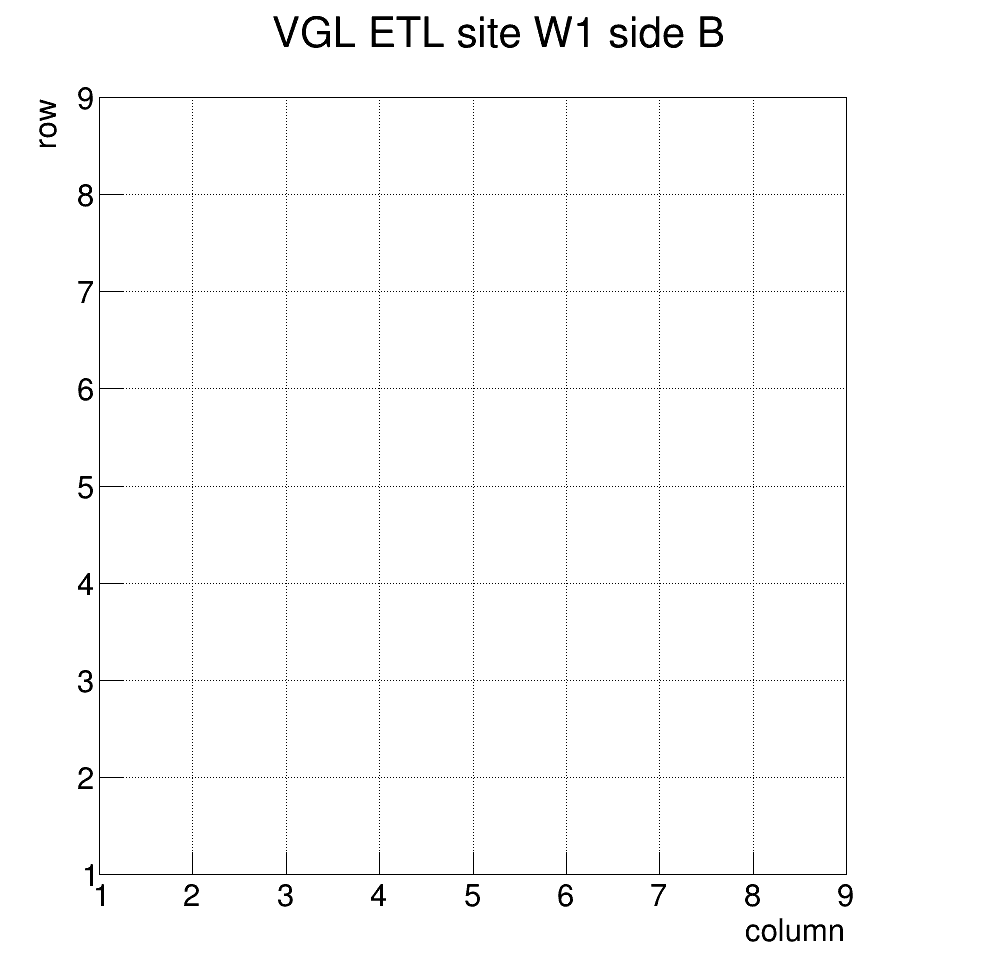

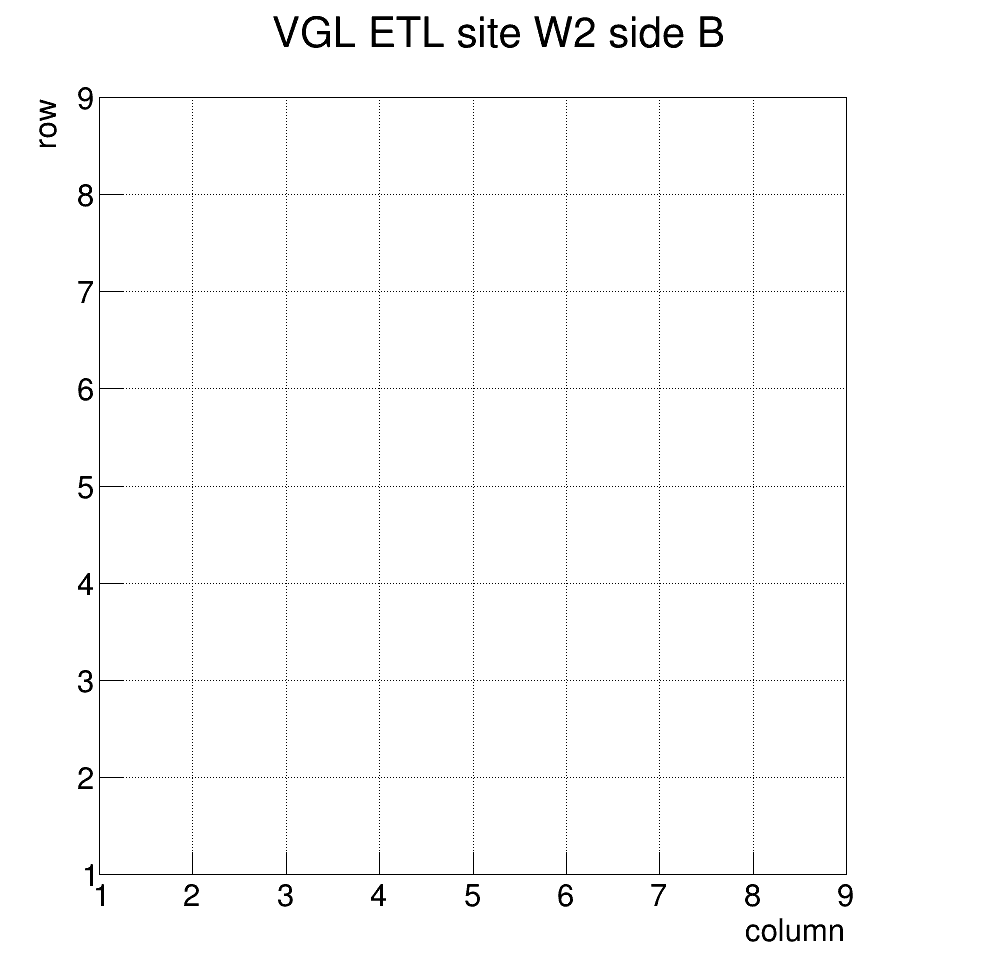

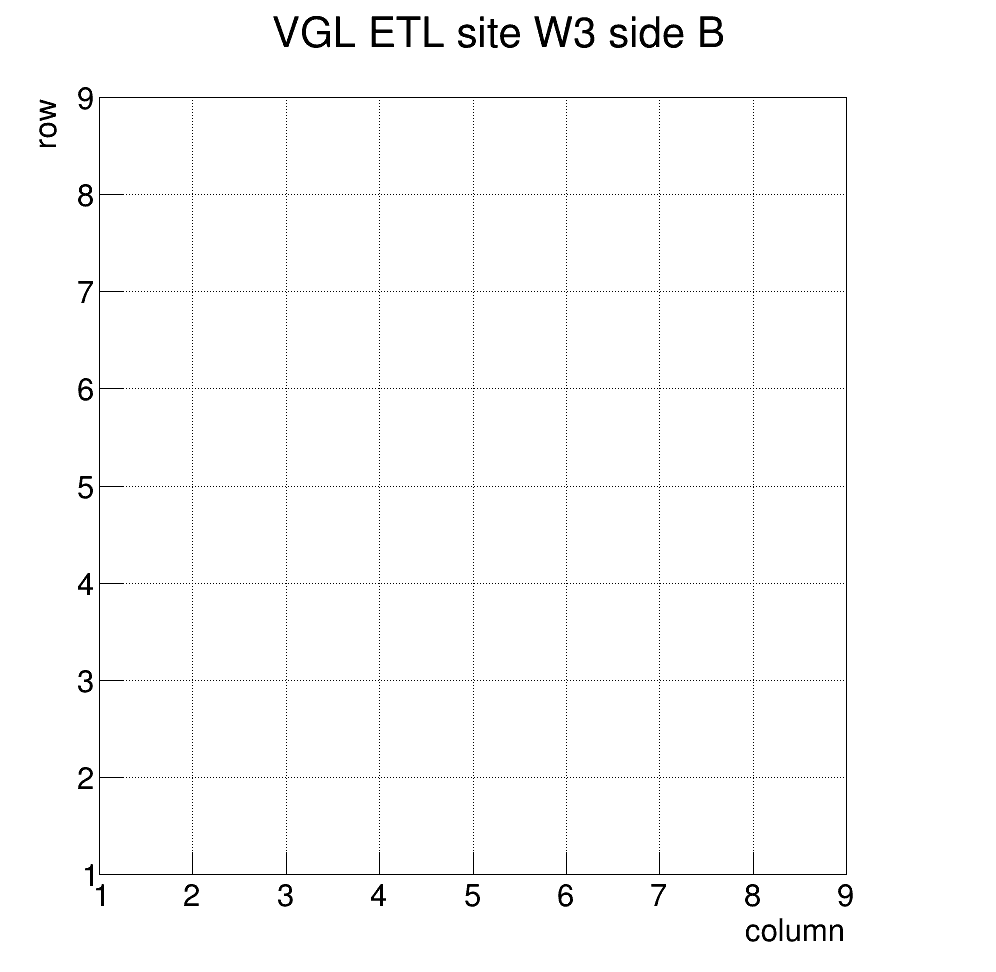

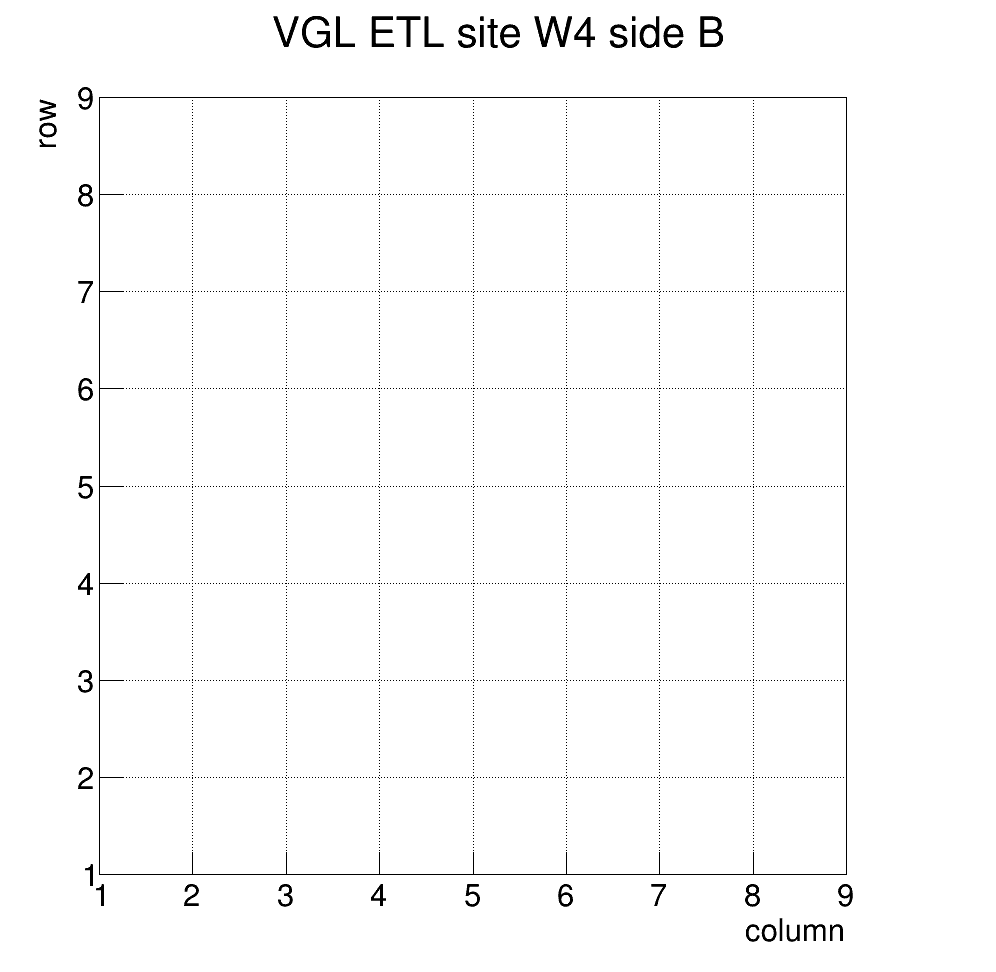

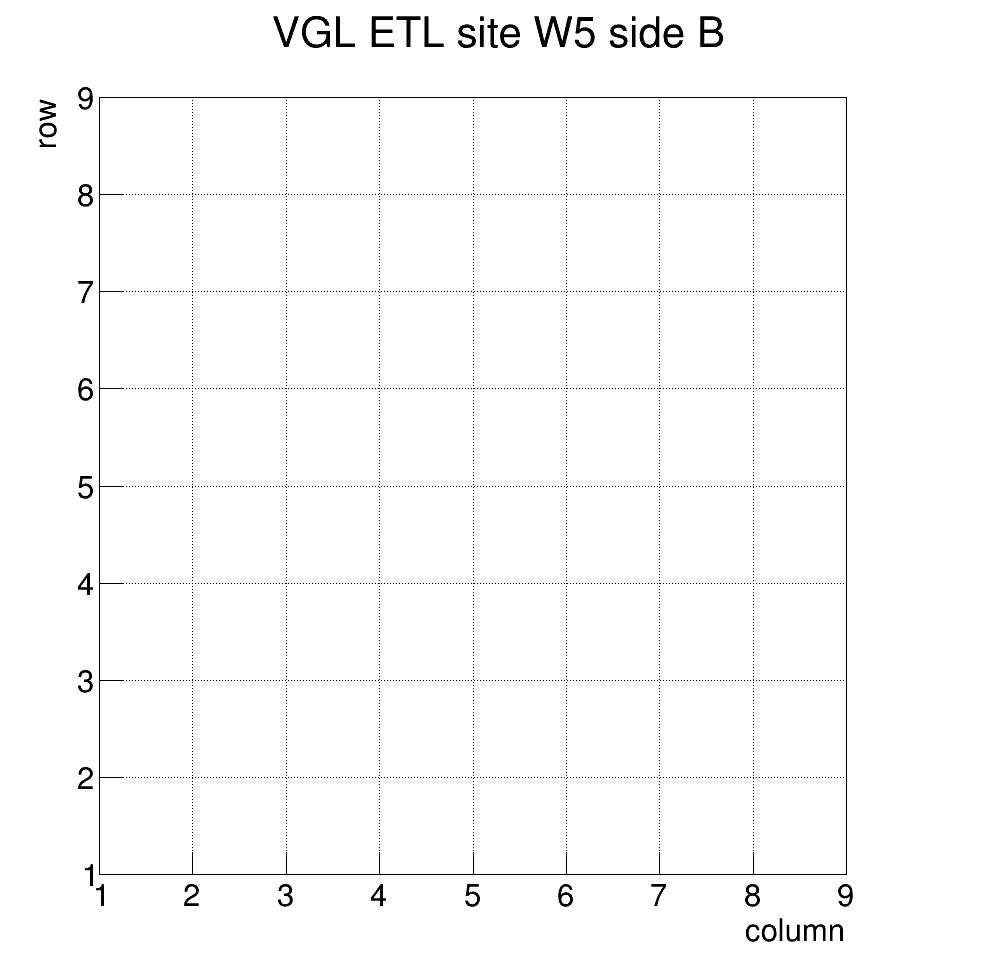

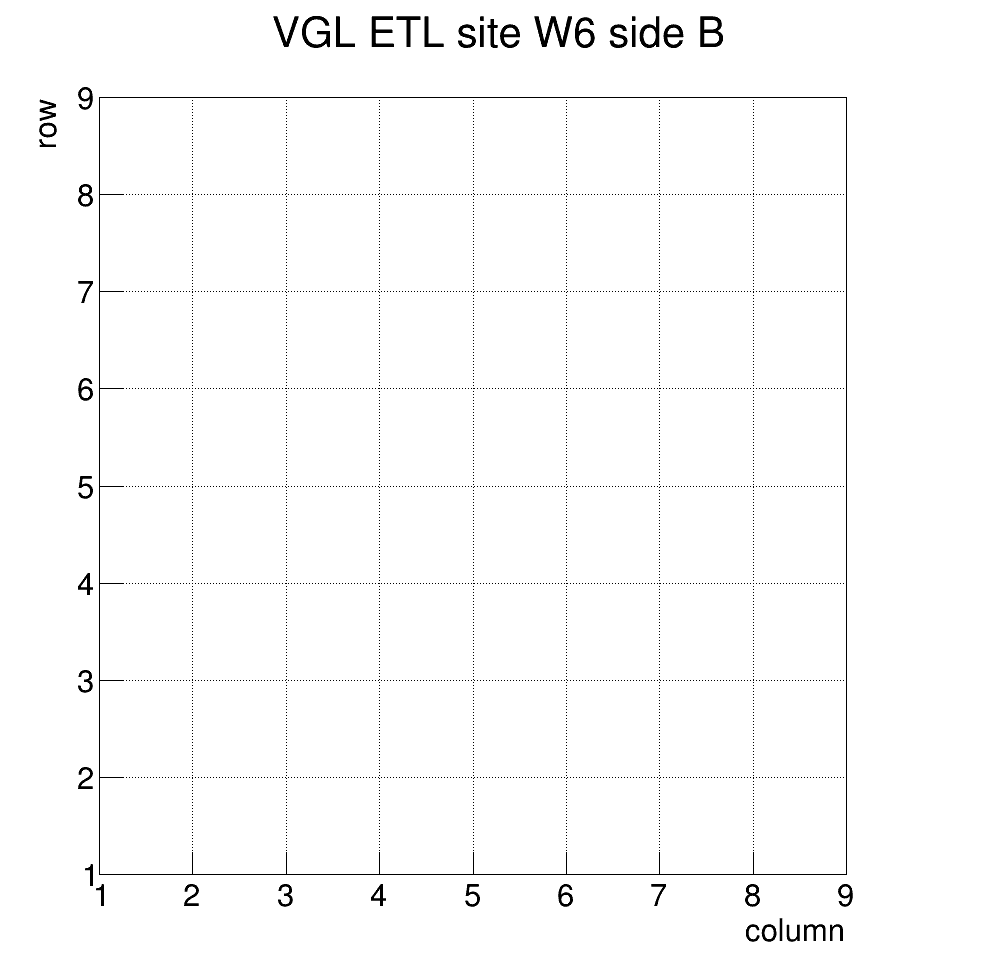

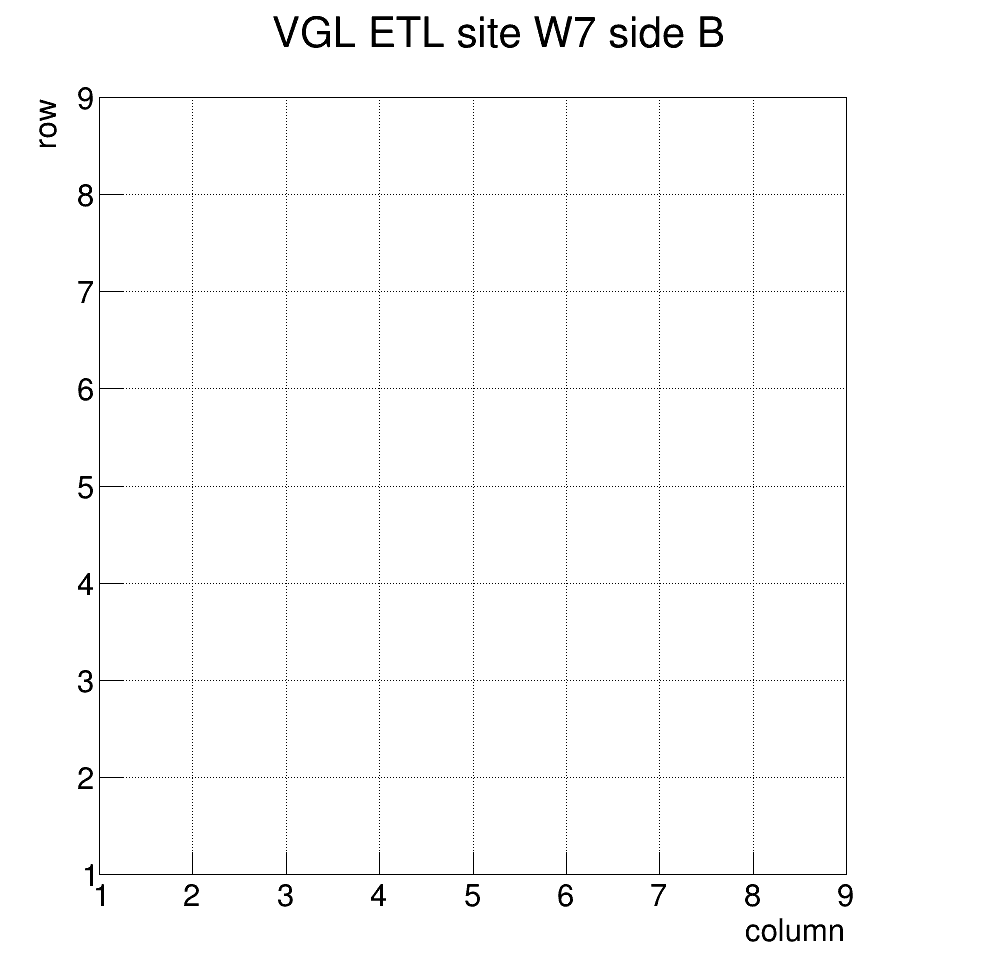

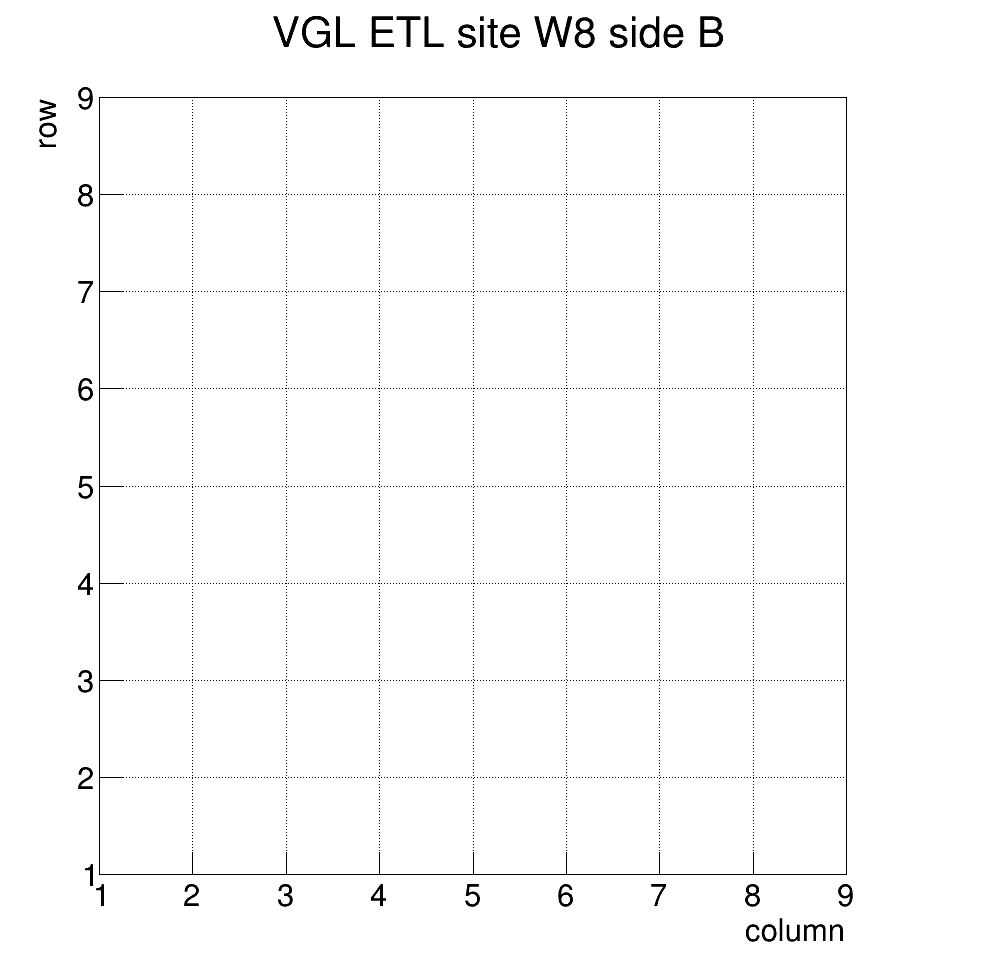

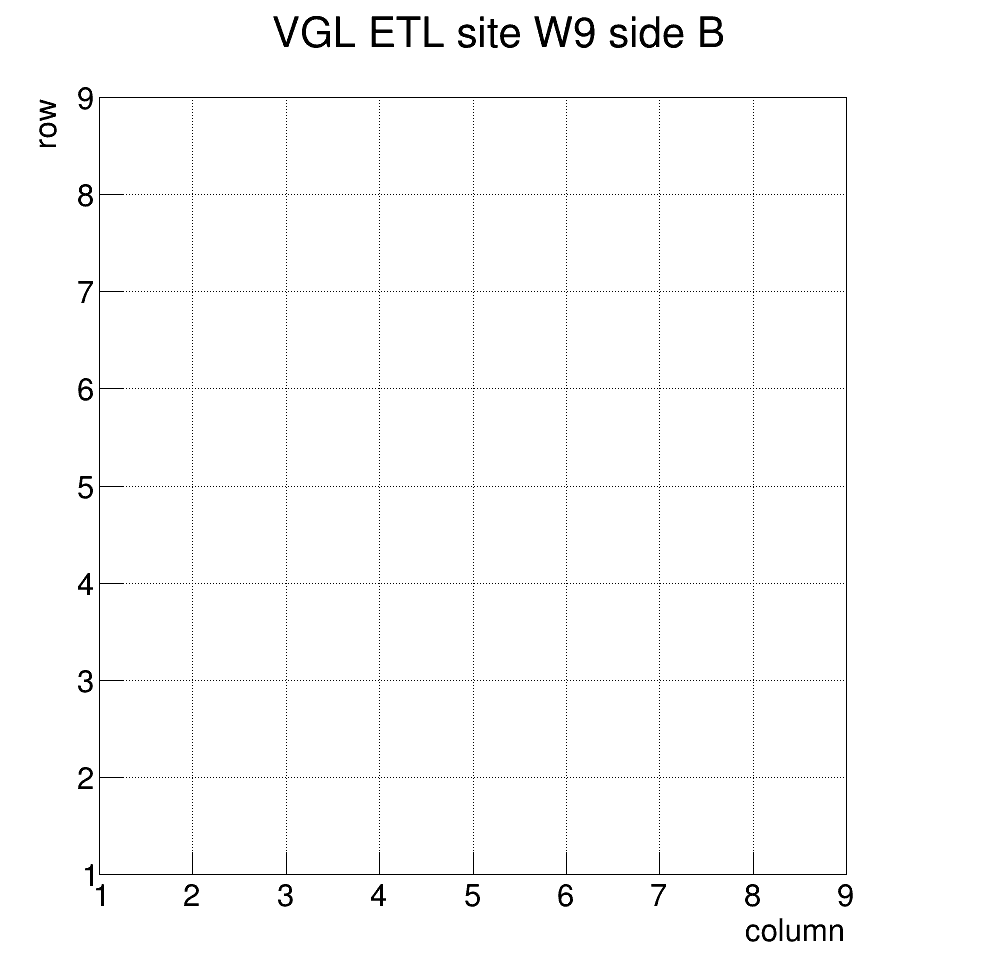

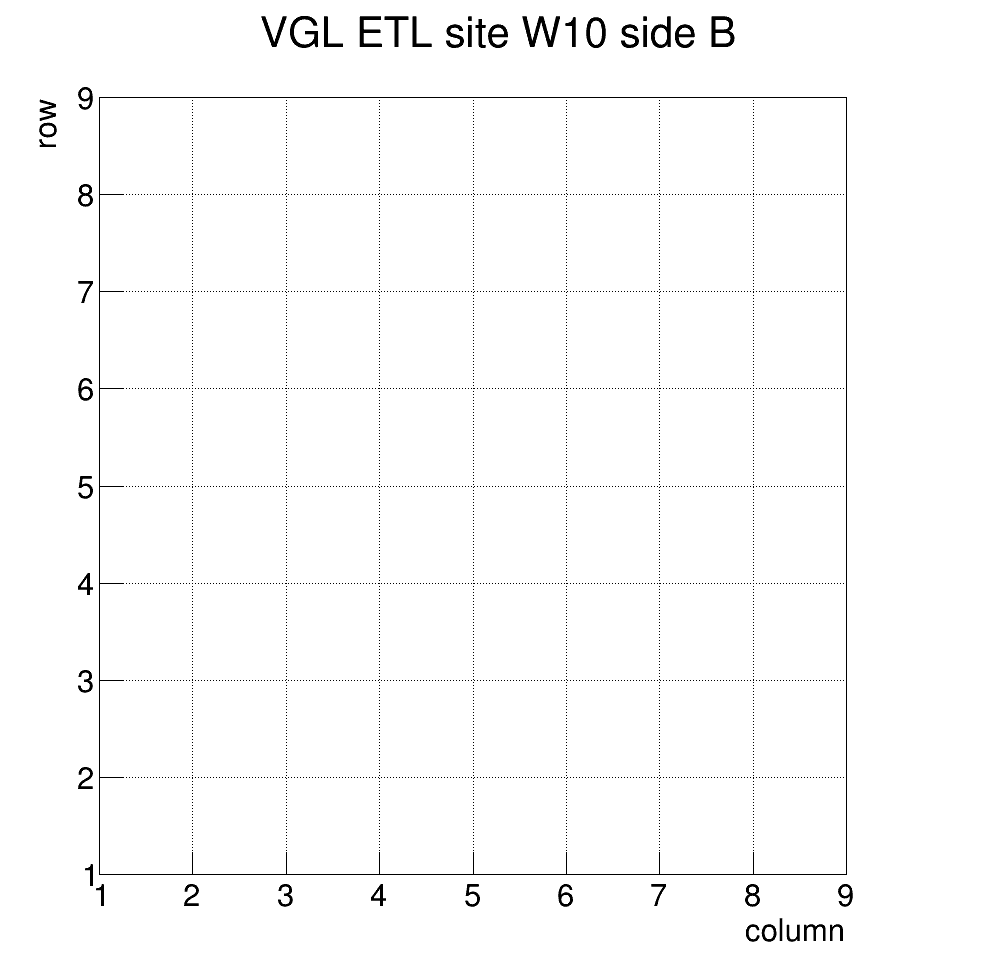

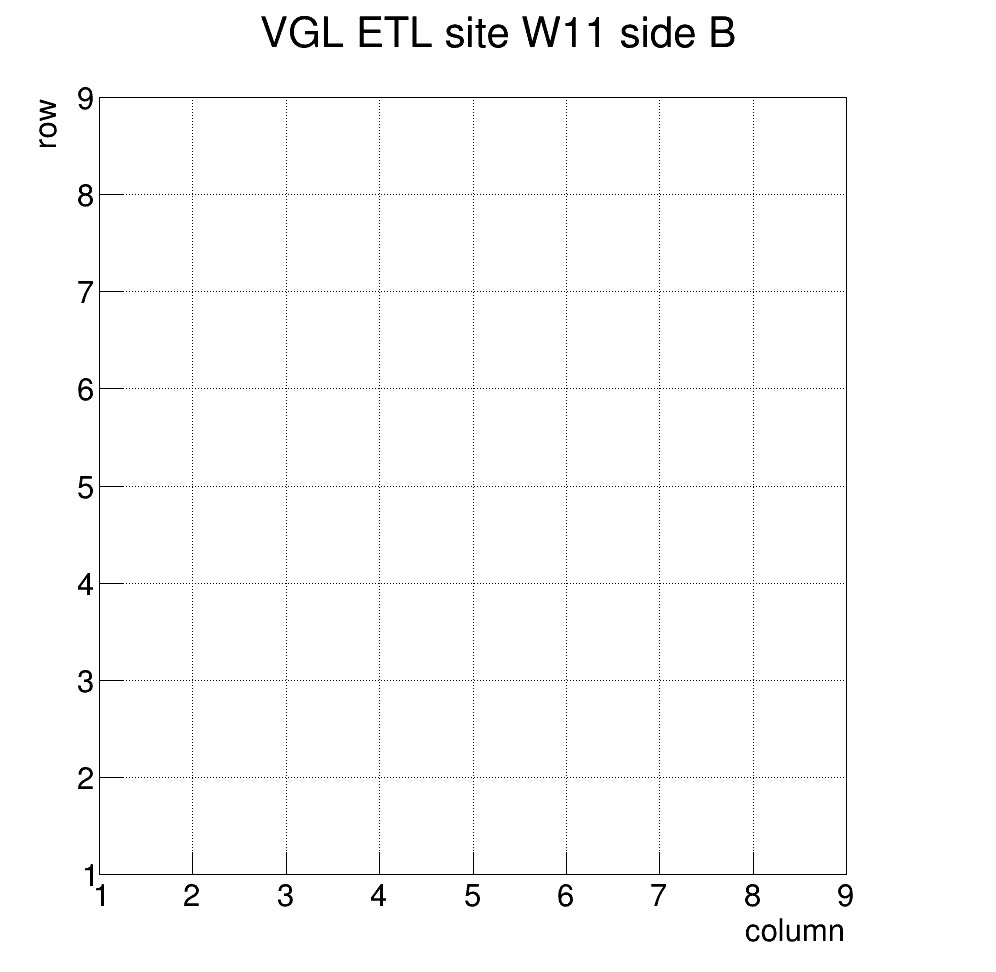

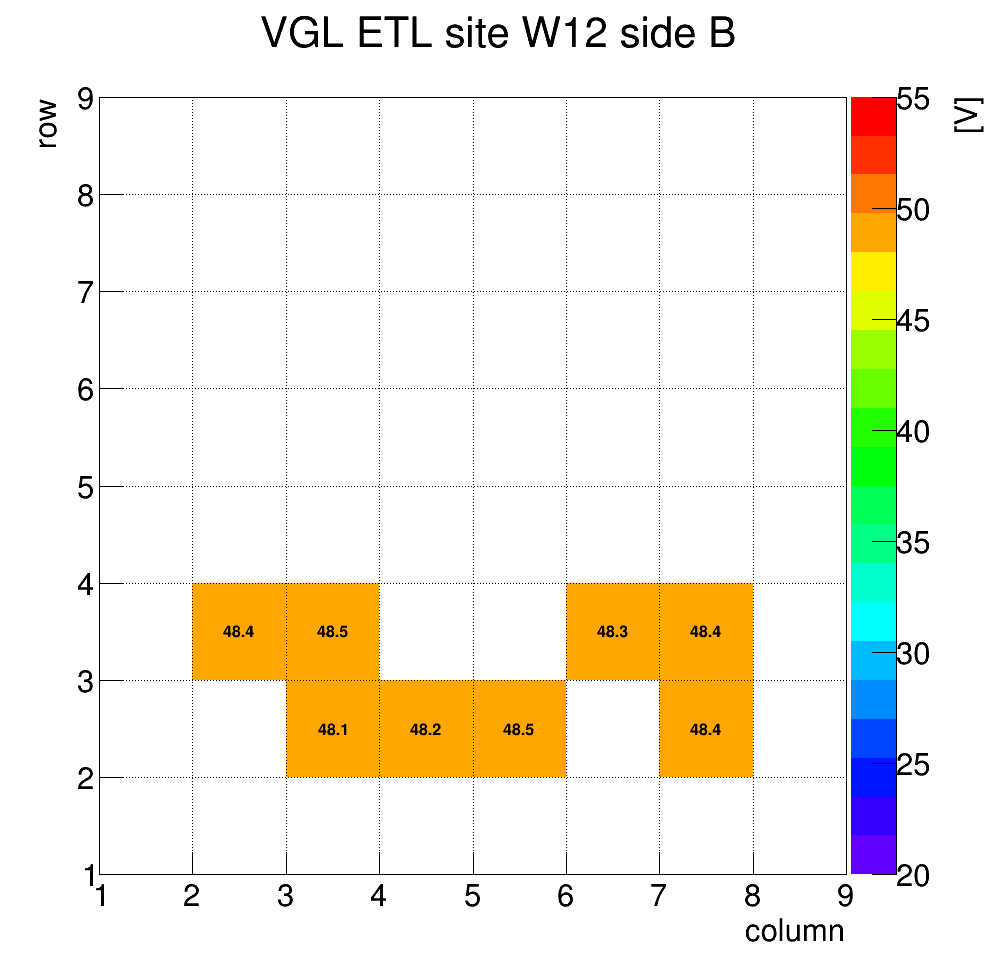

In [6]:
cC = []

for i in range(n_wafer):
 #if( i==0 ):
 if( i<15 ):
    cC.append(root.TCanvas("c_C_W"+str(i+1), "c VGL_W"+str(i+1), 1000,1000))
    #hVgl_qa[i].GetZaxis().SetRangeUser( low_GL_bias[i], high_bulk_bias[i] )
    hVgl_qa[i].GetZaxis().SetRangeUser( 20., 55. ) # Tender acceptance ranges
    hVgl_qa[i].GetZaxis().SetTitle("[V]")
    hVgl_qa[i].GetXaxis().SetTitle("column") 
    hVgl_qa[i].GetYaxis().SetTitle("row")
    hVgl_qa[i].SetMarkerSize(3.)

    root.gStyle.SetPaintTextFormat("1.1f")
    #cV.append(root.TCanvas("c_V_W"+str(i+1), "c VBD_W"+str(i+1), 1000,1000))
    cC[i].SetRightMargin(0.15)
    cC[i].cd()
    hVgl_qa[i].SetMarkerSize(0.9)
    hVgl_qa[i].Draw("textcolz")
    root.gPad.SetGrid(1,1)
    root.gPad.Update()
    cC[i].Update()
    hVgl_qa[i].GetXaxis().SetNdivisions(n_col)
    hVgl_qa[i].GetYaxis().SetNdivisions(n_row)
  
    if(save): 
      cC[i].SaveAs(save_path+"VGL_W"+str(i+1)+"_side_"+str(side)+".png")    

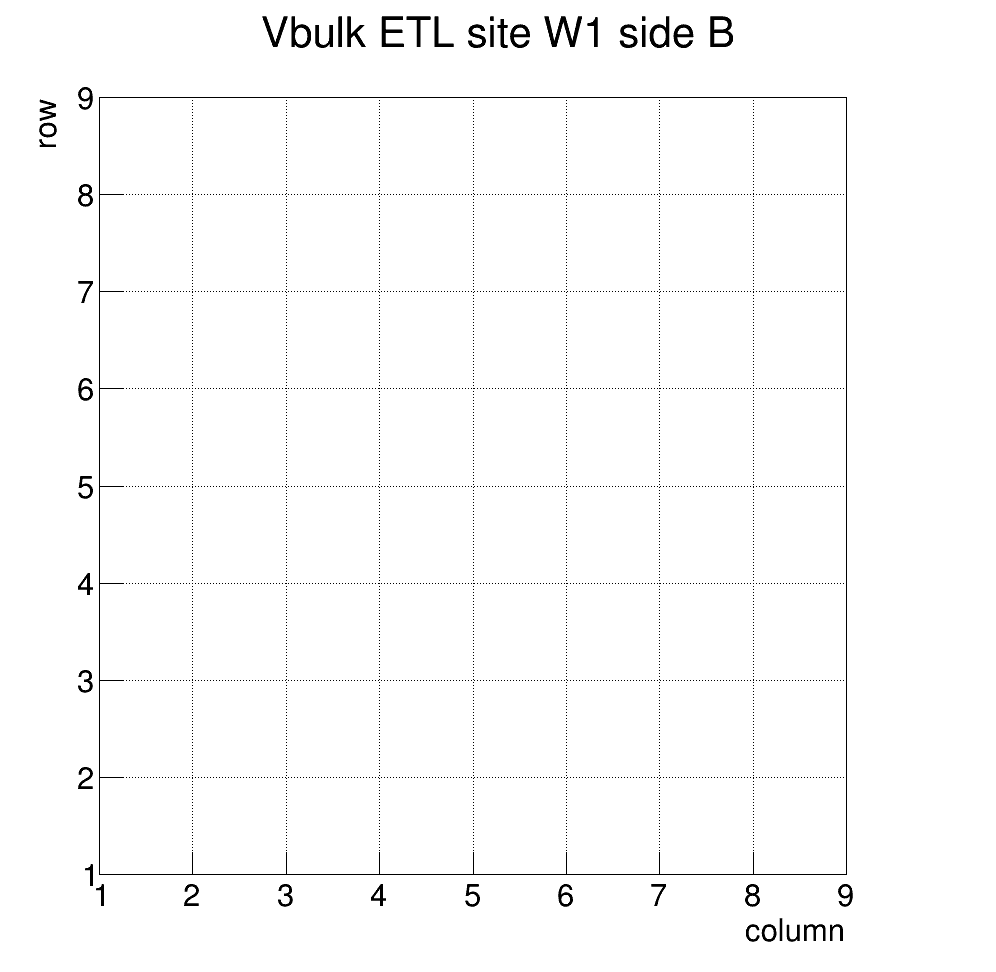

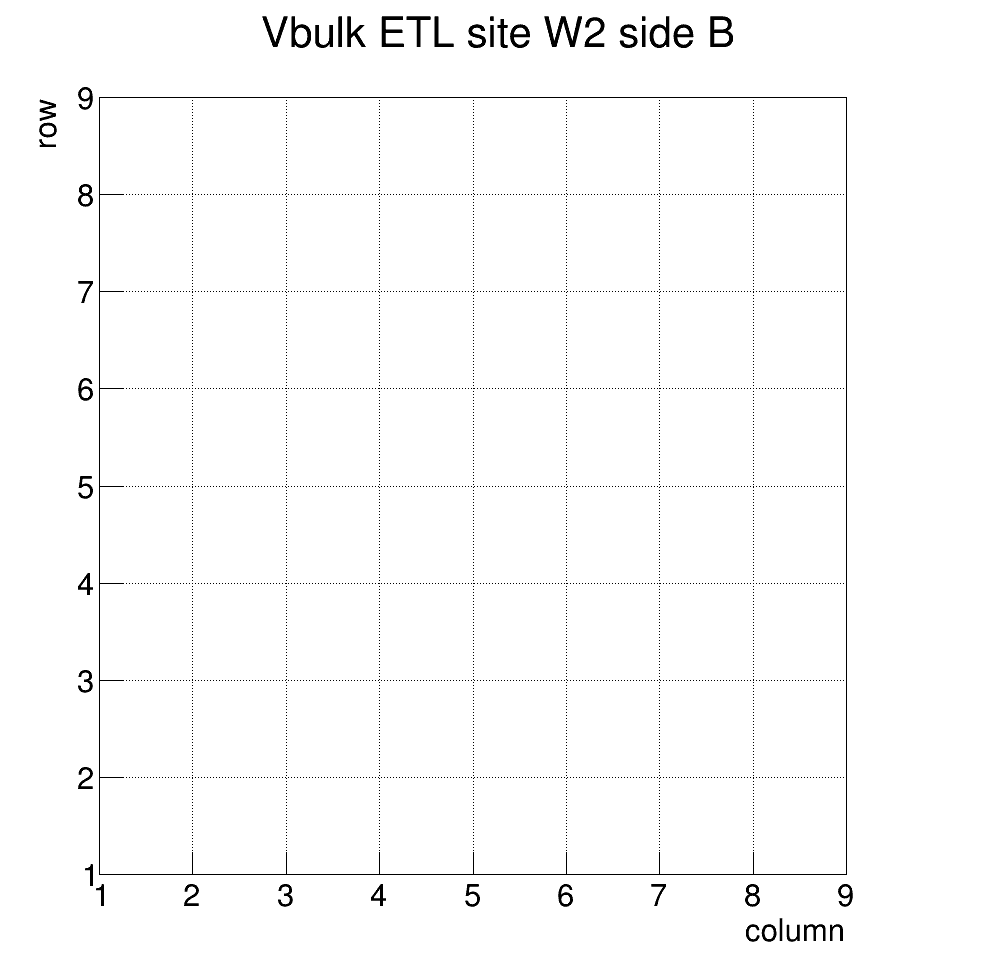

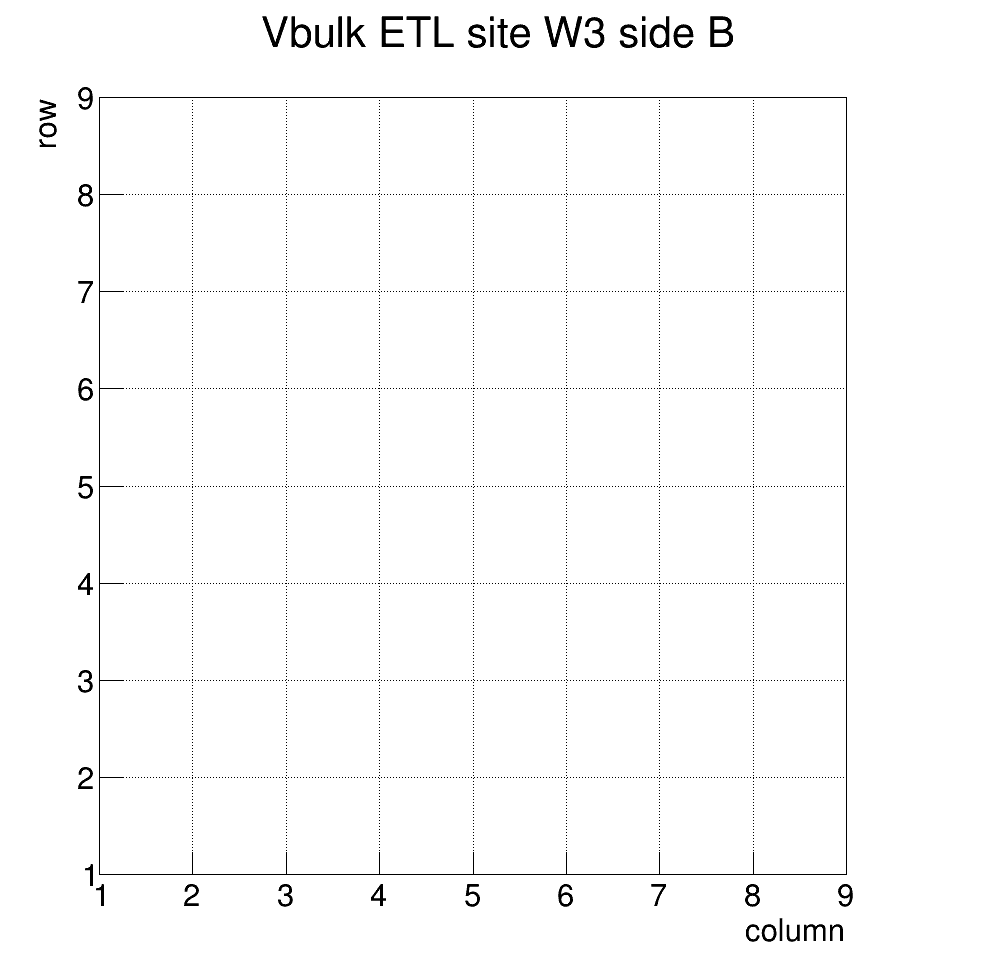

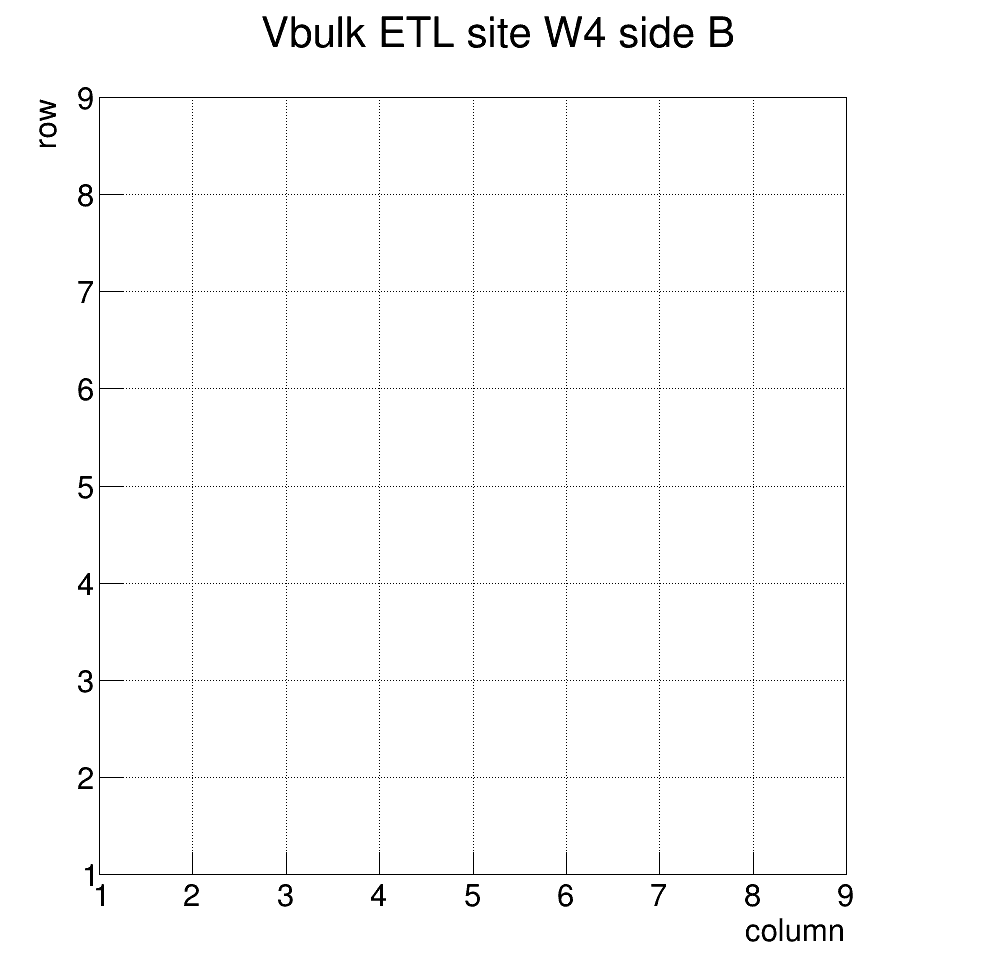

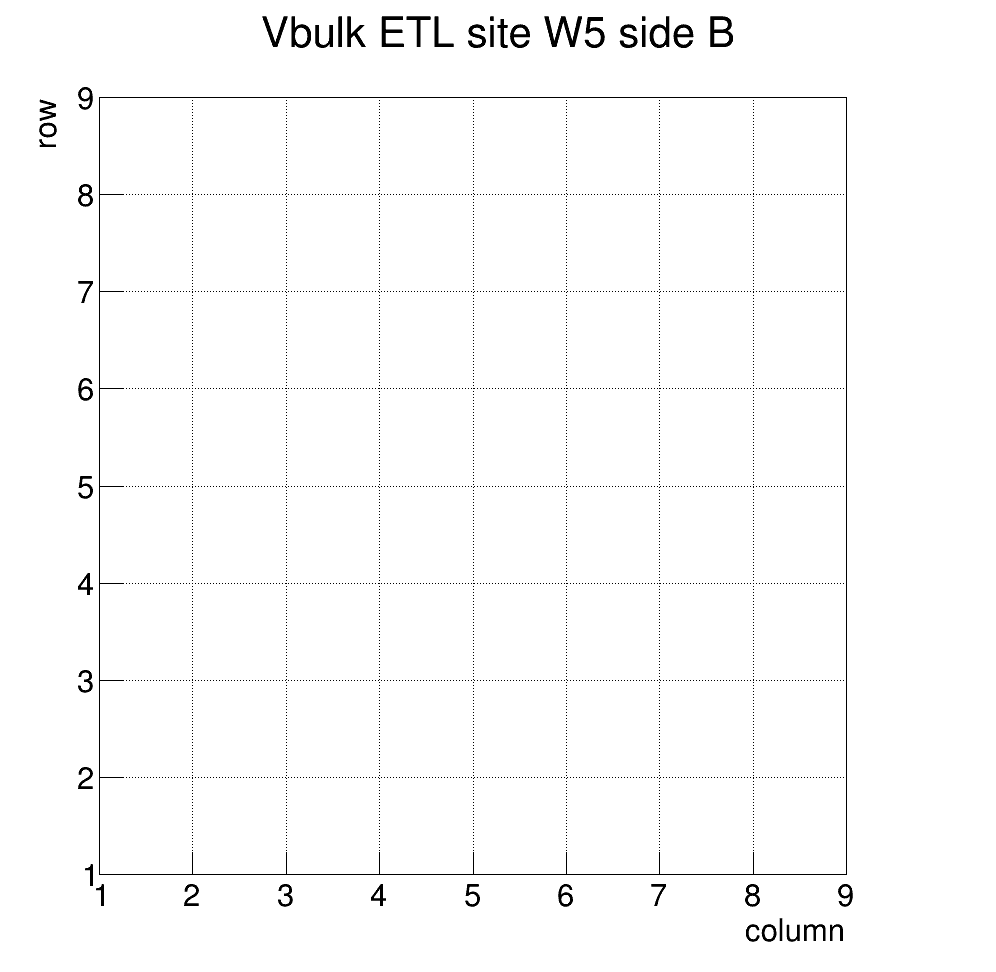

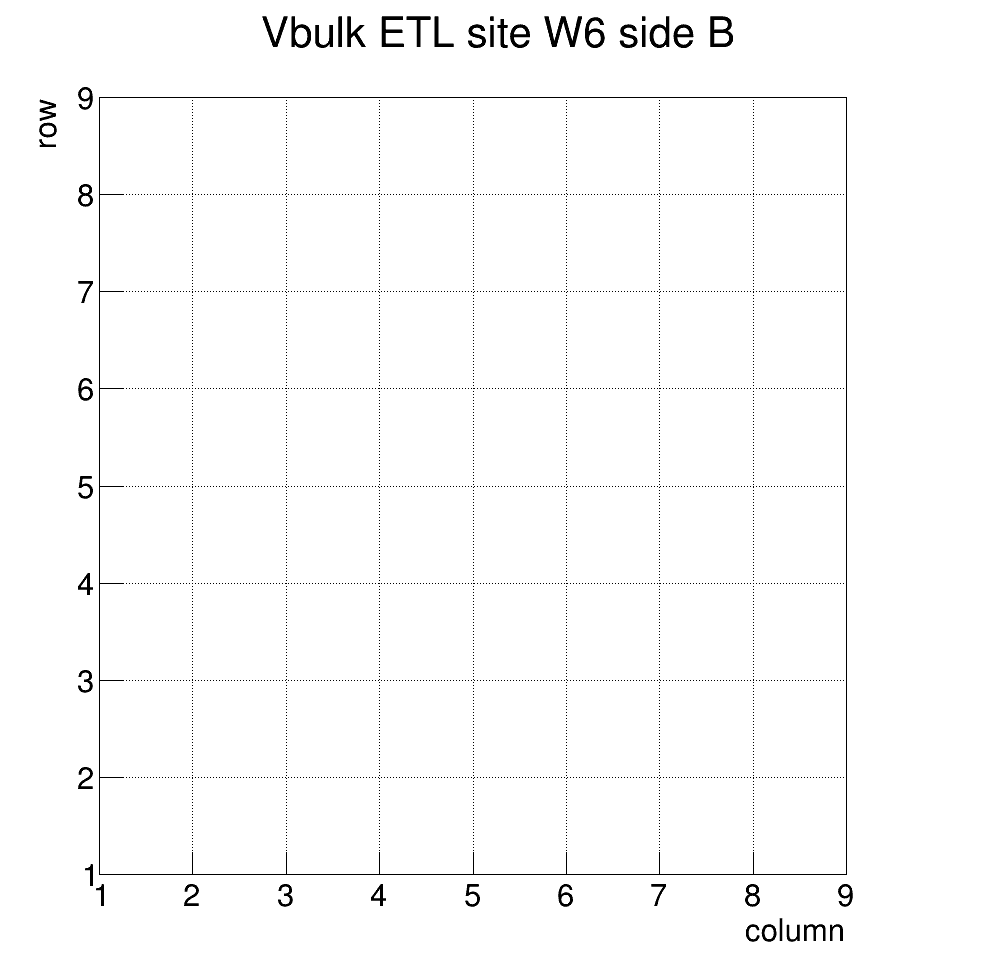

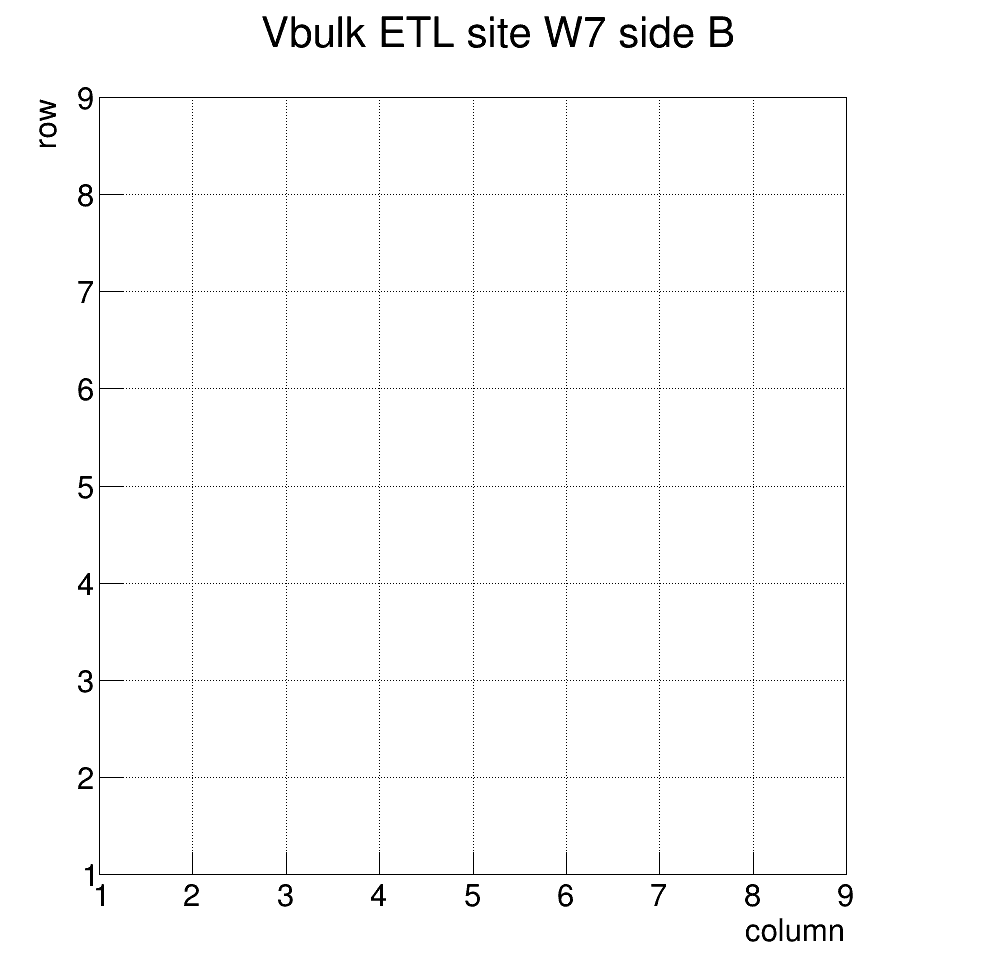

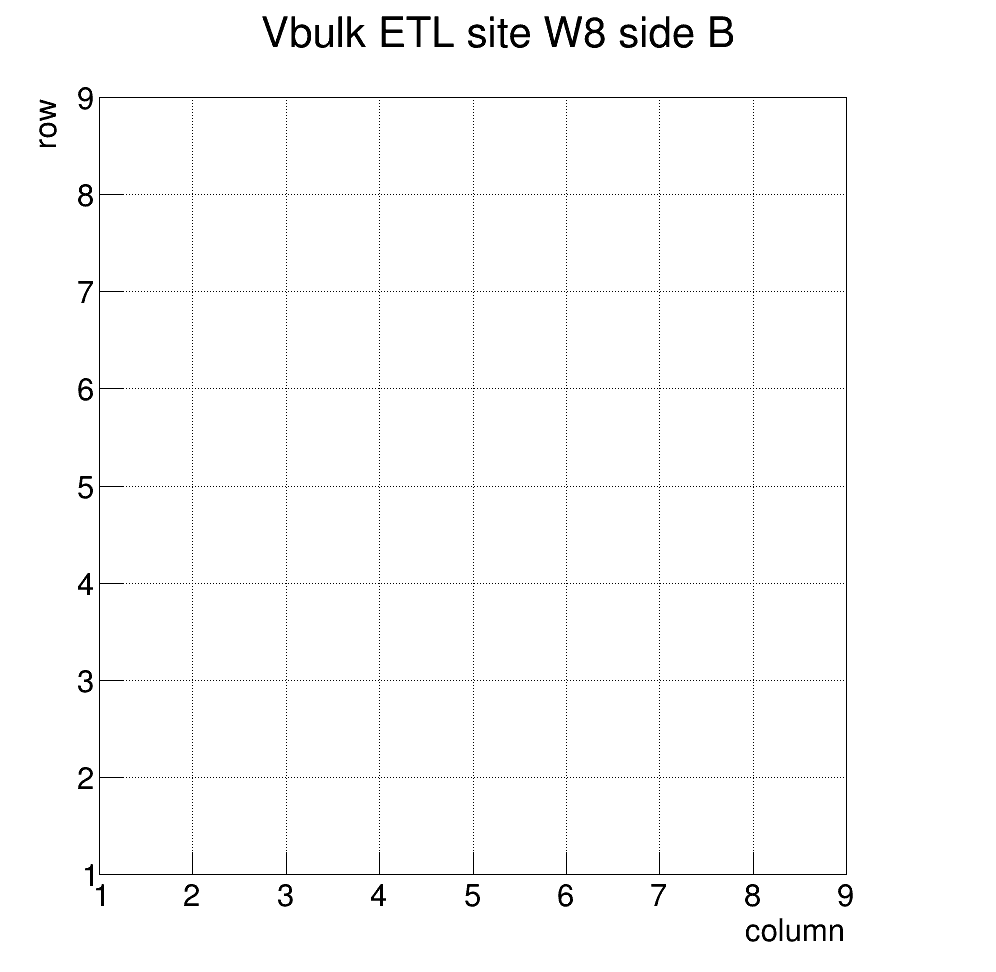

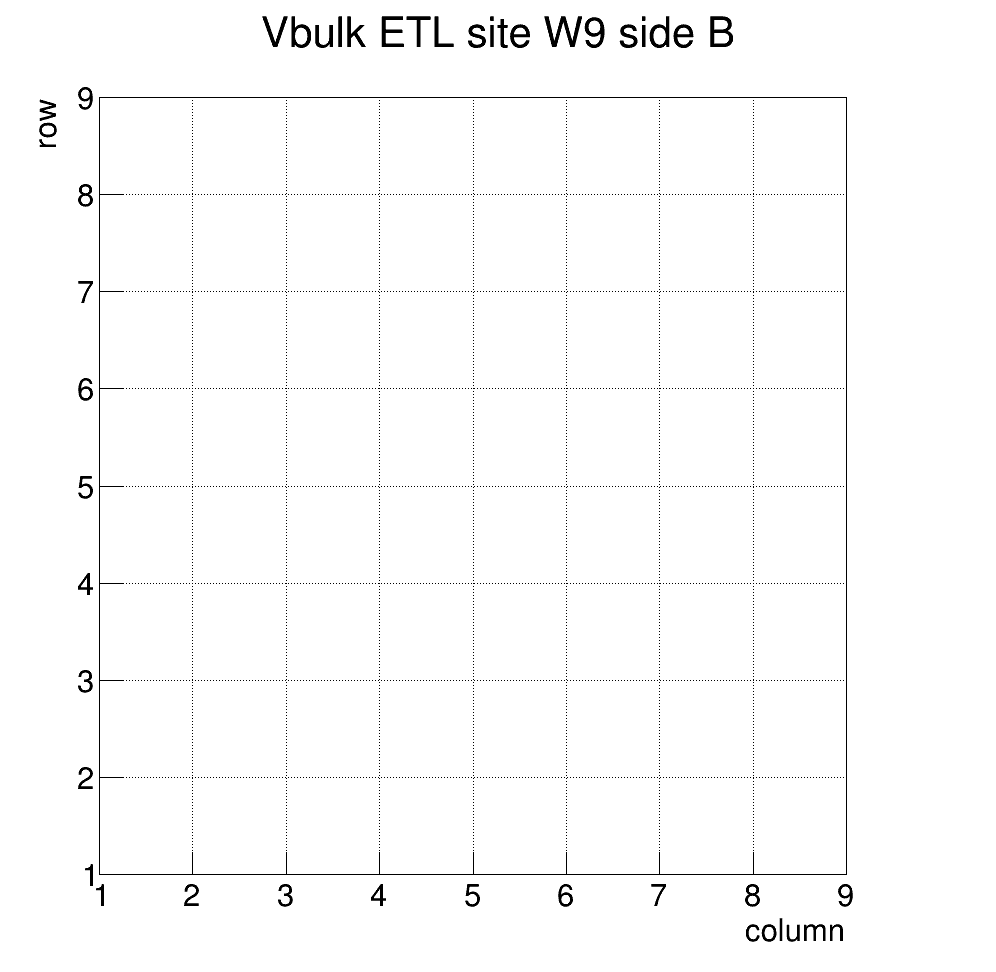

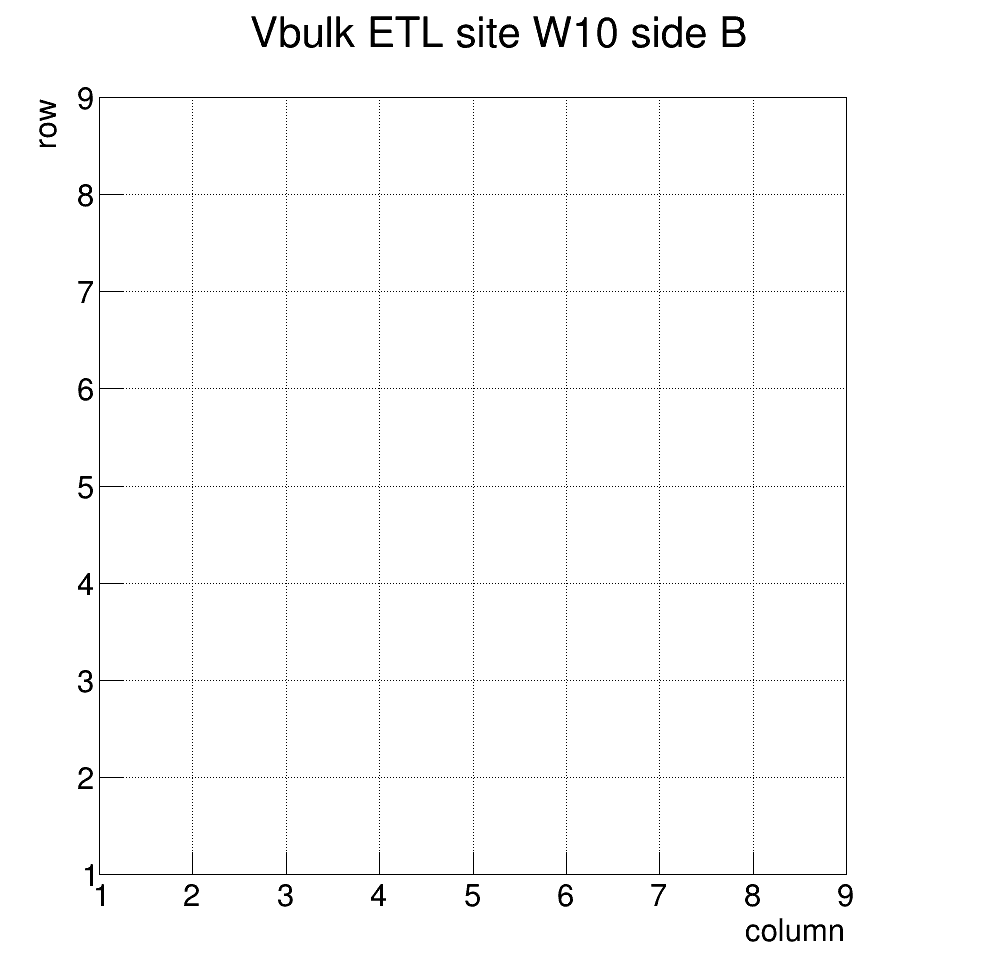

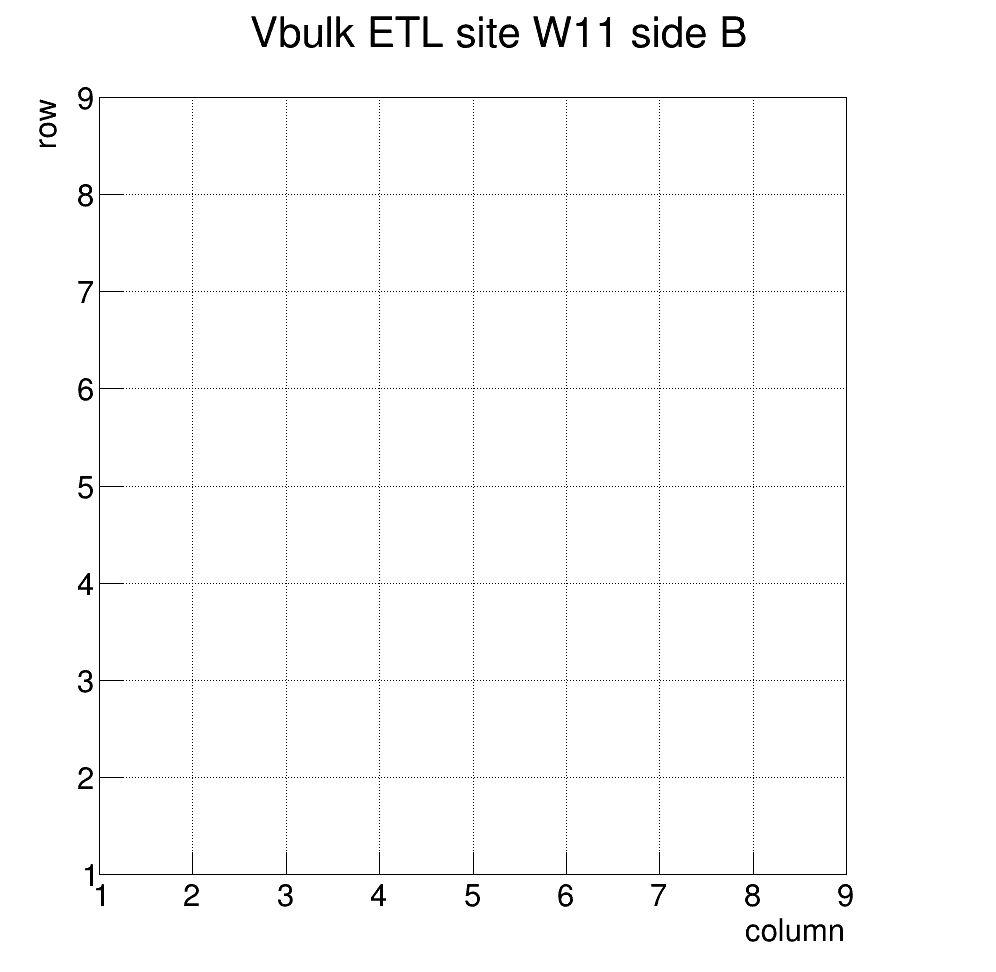

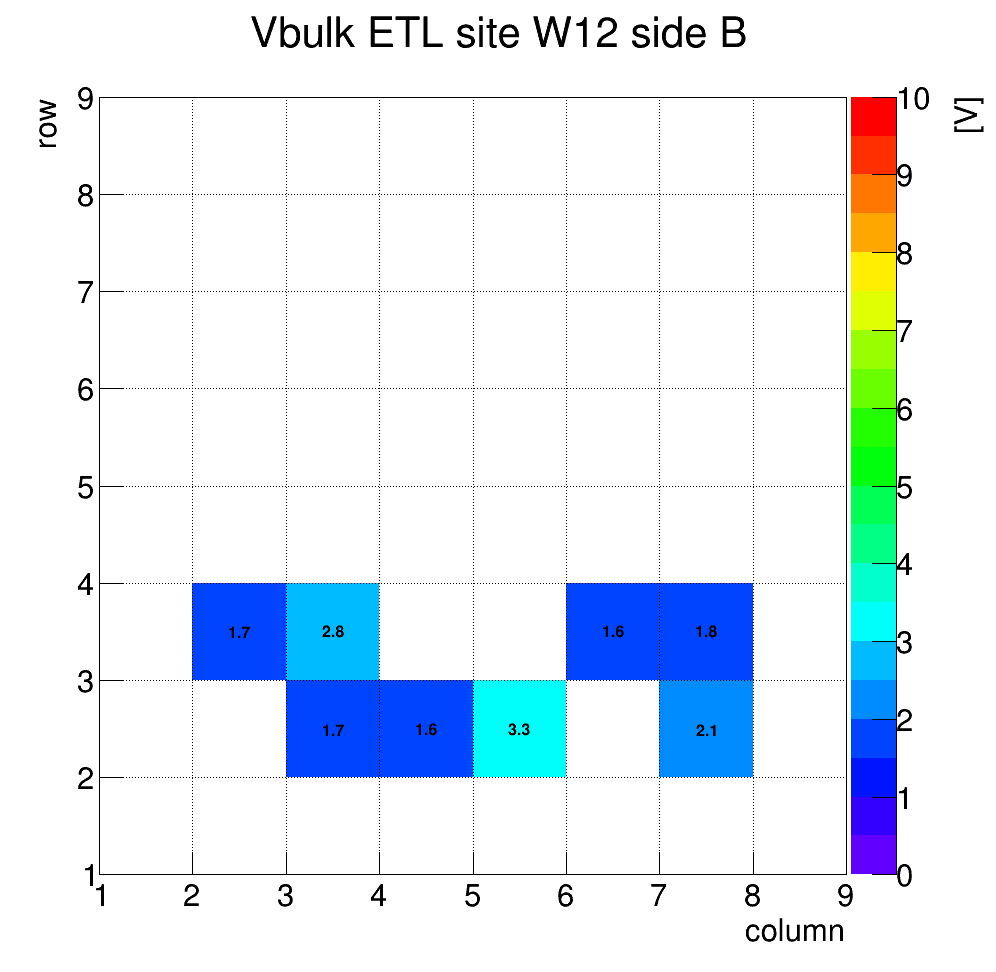

In [7]:
cD = []

for i in range(n_wafer):
 #if( i==0 ):
 if( i<15 ):
    cD.append(root.TCanvas("c_D_W"+str(i+1), "c Vbulk_W"+str(i+1), 1000,1000))
    hVbulk_qa[i].GetZaxis().SetRangeUser( 0., 10. ) # Tender acceptance ranges
    hVbulk_qa[i].GetZaxis().SetTitle("[V]")
    hVbulk_qa[i].GetXaxis().SetTitle("column") 
    hVbulk_qa[i].GetYaxis().SetTitle("row")
    hVbulk_qa[i].SetMarkerSize(3.)

    root.gStyle.SetPaintTextFormat("1.1f")
    #cV.append(root.TCanvas("c_V_W"+str(i+1), "c VBD_W"+str(i+1), 1000,1000))
    cD[i].SetRightMargin(0.15)
    cD[i].cd()
    hVbulk_qa[i].SetMarkerSize(0.9)
    hVbulk_qa[i].Draw("textcolz")
    root.gPad.SetGrid(1,1)
    root.gPad.Update()
    cD[i].Update()
    hVbulk_qa[i].GetXaxis().SetNdivisions(n_col)
    hVbulk_qa[i].GetYaxis().SetNdivisions(n_row)
  
    if(save): 
      cD[i].SaveAs(save_path+"Vbulk_W"+str(i+1)+"_side_"+str(side)+".png")    